In [87]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_predict

# Para clustering
from sklearn.preprocessing import MinMaxScaler 
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Para componentes principales
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Para KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

### Preprocesamiento

In [37]:
# 1.
data = pd.read_csv("FBRef2020-21.csv")

In [38]:
# 2.
data = data[data['Min'] > 500]

In [39]:
# 3.
to_drop = data.isna().sum()
data.drop(columns=[col for col in to_drop.index if to_drop[col] >= 100], inplace=True)
data.dropna(inplace=True)

In [49]:
# 4.
# ( No encontre esos valores)
percent_cols = [col for col in data.columns if col.startswith('%')]
data.drop(columns=percent_cols, inplace=True)

In [50]:
# 5.
data.reset_index(drop=True, inplace=True)

In [51]:
# 6
idx = list(data.columns).index('Ast/90')
data_num = data.drop(columns=data.columns[:idx])

### Clustering

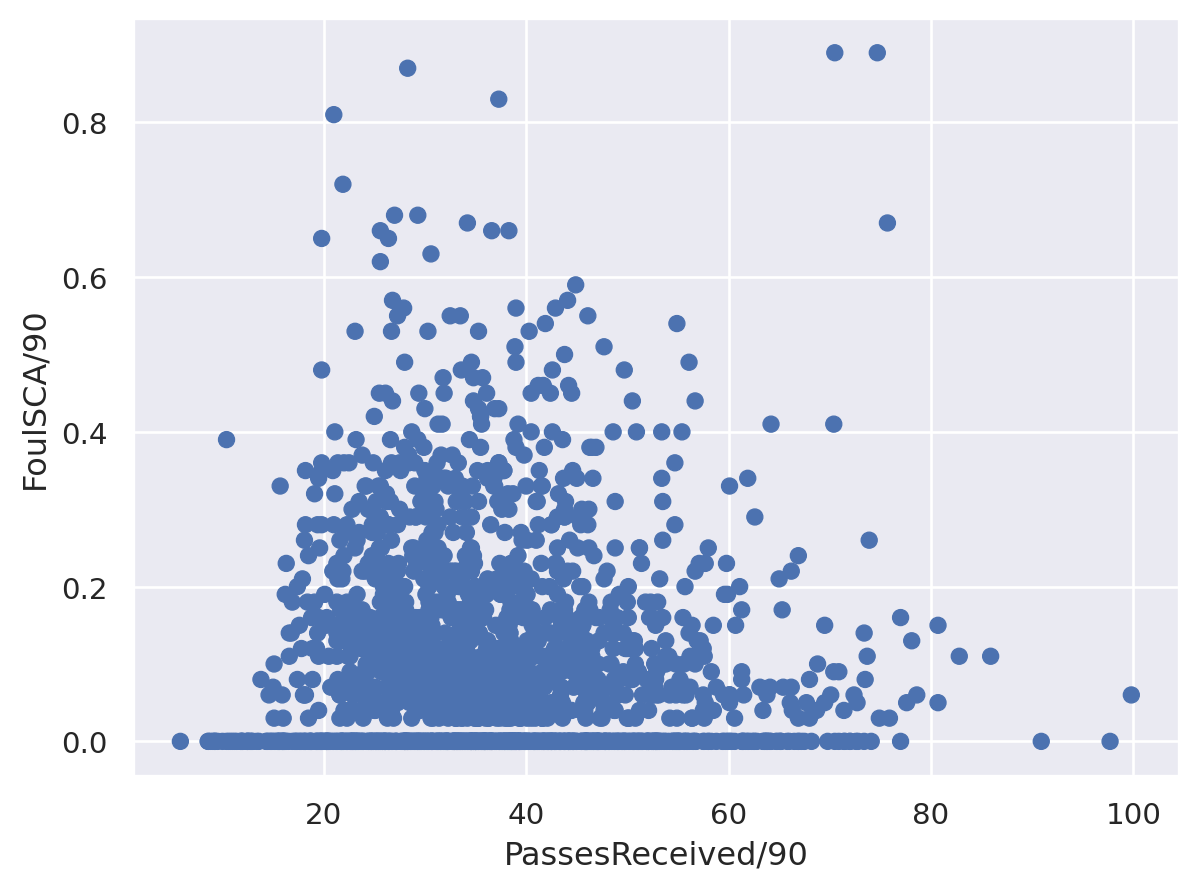

In [54]:
#A.
data_num.head()
(
    so.Plot(data=data_num, x='PassesReceived/90', y='FoulSCA/90')
    .add(so.Dot())
)

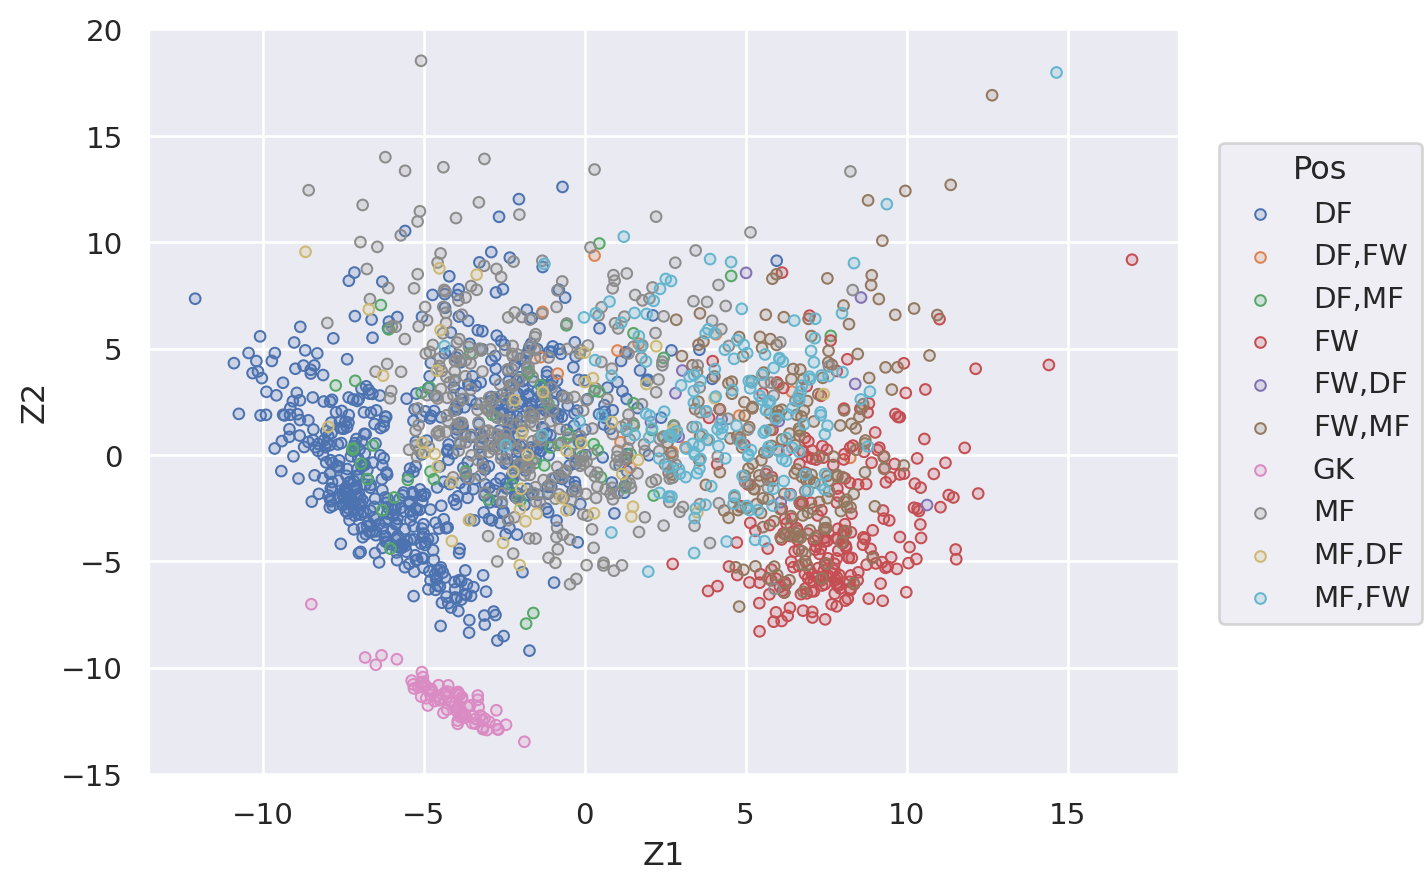

In [71]:
# B.
pca = PCA(n_components=2)
data_num_star = StandardScaler().set_output(transform="pandas").fit_transform(data_num)
principalComponents = pca.fit_transform(data_num_star)

pComp = pd.DataFrame(principalComponents).set_index(data_num_star.index)
pComp.columns = ["Z1", "Z2"]

pCompPos = pd.concat([pComp, data[["Player", "Pos"]]], axis = 1)
(
    so.Plot(data=pCompPos, x='Z1', y='Z2', color='Pos')
    .add(so.Dots())
)

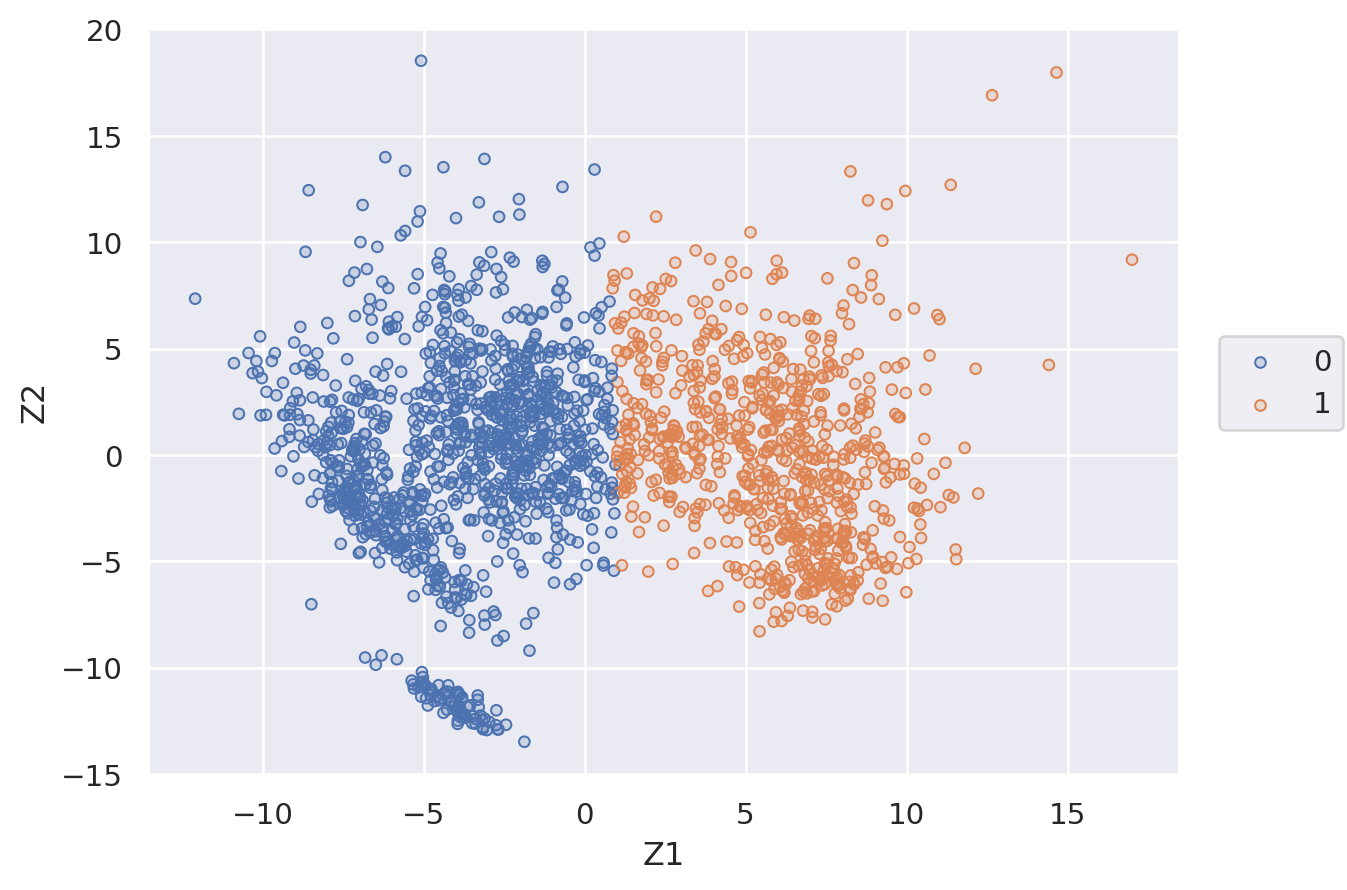

In [69]:
# C.
kmeans = KMeans(n_clusters=2)
cluster = kmeans.fit_predict(pComp)
(
    so.Plot(data = pComp, x = "Z1", y = "Z2", color = cluster.astype(str))
    .add(so.Dots())
)

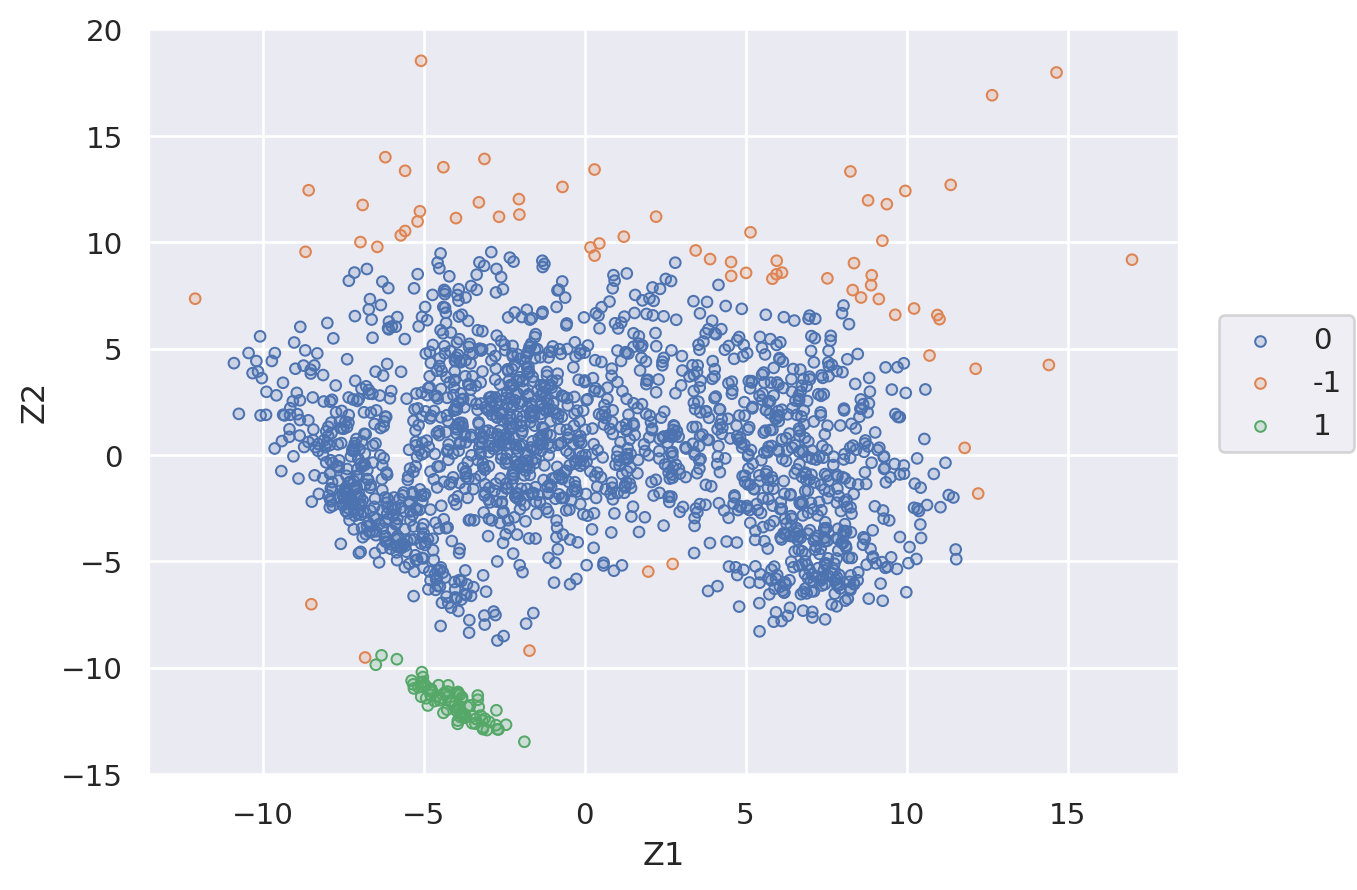

In [70]:
# D.
clustering = DBSCAN(eps=1.5, min_samples=15)
etiqueta = clustering.fit_predict(pComp)
(
    so.Plot(data = pComp, x = "Z1", y = "Z2", color = etiqueta.astype("str"))
    .add(so.Dots())
)

In [ ]:
# E. ?

### Clasificación

In [81]:
# A.
data_clasif = pd.concat([data['Pos'].str.split(',').str[0], data_num], axis=1)


In [85]:
# B.
df_train, df_test = train_test_split(data_clasif, test_size=0.2, random_state=11)
X_train = df_train.drop(columns=['Pos'])
y_train = df_train['Pos']


In [91]:
# C.
leave_one = LeaveOneOut()
errors = []

for K in range(2, 20):
    classifier = KNeighborsClassifier(n_neighbors=K)  
    y_pred = cross_val_predict(classifier, X_train, y_train, cv=leave_one)
    errors.append(np.mean(y_pred != y_train))
    
best_K = errors.index(min(errors)) + 2
best_K

6

In [93]:
# D.
X_test = df_test.drop(columns=['Pos'])
y_test = df_test['Pos']

classifier = KNeighborsClassifier(n_neighbors=6)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.8131578947368421

In [99]:
# 9.
data_fem = pd.read_csv('female2023.csv')
data_fem.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,Per90Minutes_Gls,Per90Minutes_Ast,Per90Minutes_G+A,Per90Minutes_G-PK,Per90Minutes_G+A-PK,Per90Minutes_xG,Per90Minutes_xAG,Per90Minutes_xG+xAG,Per90Minutes_npxG,Per90Minutes_npxG+xAG
0,1,Princess Ademiluyi,eng ENG,"MF,FW",West Ham,17.0,2006.0,11,0,87,...,0.0,1.03,1.03,0.0,1.03,0.03,0.00,0.03,0.03,0.03
1,2,Michelle Agyemang,eng ENG,FW,Arsenal,17.0,2006.0,1,0,6,...,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2,3,Alyssa Aherne,eng ENG,MF,Everton,19.0,2004.0,1,0,1,...,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
3,4,Olga Ahtinen,fi FIN,MF,Tottenham,NaN,NaN,16,10,923,...,0.1,0.20,0.29,0.1,0.29,0.04,0.12,0.15,0.04,0.15
4,5,Asmita Ale,eng ENG,DF,Leicester City,21.0,2001.0,6,4,296,...,0.0,0.00,0.00,0.0,0.00,0.06,0.00,0.06,0.06,0.06


### Recomendaciones

In [105]:
money = pd.read_csv('transfermarkt_fbref_201920.csv', delimiter=';')
money[money['value'] > 100000].shape

(2219, 400)